## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_ID = 'EL51'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.293398,-1.643682,1.824858,5.319432,NaN,NaN,NaN,-0.739066,NaN,NaN,NaN,2.290183,NaN,NaN,NaN,7.036106,9.142565e+01,1.297637e+02,2.179013e+02,218.119280,31.387255,1.012492,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280,0,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,NaN,NaN
1,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.769895,-1.152583,2.808656,6.769895,NaN,NaN,NaN,-0.479640,NaN,NaN,NaN,3.145128,NaN,NaN,NaN,9.791599,1.392955e+02,2.074087e+02,3.034552e+02,303.539567,31.000000,1.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.0,1.0,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-5.288987,12.493000,303.539567,0,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,10590.0,37198.0,7334.0,55122.0,9955.0,36599.0,9263.0,55817.0,1544.09,NaN,NaN
2,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.184231,-0.670160,3.257036,7.231715,NaN,NaN,NaN,0.014150,NaN,NaN,NaN,3.622932,NaN,NaN,NaN,8.572965,1.408672e+02,1.873860e+02,2.657269e+02,265.761927,31.000000,1.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.0,1.0,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2,-4.623871,12.565323,265.761927,0,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.6666

In [4]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y_LT15']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y_LT15']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [5]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y15-64']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y15-64']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [6]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y_GE65']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y_GE65']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [7]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [8]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y_LT15']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y_LT15']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [9]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y15-64']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y15-64']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [10]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y_GE65']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y_GE65']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [11]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [12]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [13]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [14]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [15]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','monthly_lst_min','monthly_lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'mosq_pred_acc','mosq_pred_mean',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min',
 'distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max',
 'distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std',
 'lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'cases']

In [16]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
nuts3_units = dataset_monthly.NUTS3_ID.unique()

In [18]:
data = []

for year in years[1:]:
    for month in months:
        for region in nuts3_units:
            df_regional = dataset_monthly.loc[(dataset_monthly['NUTS3_ID'] == region)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()
            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'NUTS3_ID': region, 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_prev_month.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_prev_month.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_prev_month.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_prev_month.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_prev_month.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_prev_month.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_prev_month.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_prev_month.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_prev_month.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_prev_month.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_prev_month.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_prev_month.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['monthly_lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['monthly_lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_prev_month.iloc[0]['acc_rainfall_jan'],

                        'mosq_pred_acc': df_prev_month.iloc[0]['mosq_pred_acc'],
                        'mosq_pred_mean': df_prev_month.iloc[0]['mosq_pred_mean'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_prev_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_prev_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_prev_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_prev_year.iloc[0]['lc_type1'],
                        'lc_type2': df_prev_year.iloc[0]['lc_type2'],
                        'lc_type3': df_prev_year.iloc[0]['lc_type3'],
                        'lc_type4': df_prev_year.iloc[0]['lc_type4'],
                        'lc_type5': df_prev_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_prev_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_prev_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_prev_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_prev_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_prev_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_prev_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_prev_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_prev_year.iloc[0]['flow_accu_200m'],

                        'distance_to_coast_min': df_prev_year.iloc[0]['distance_to_coast_min'],
                        'distance_to_river_min': df_prev_year.iloc[0]['distance_to_river_min'],
                        'slope_mean_1km_min': df_prev_year.iloc[0]['slope_mean_1km_min'],
                        'aspect_mean_200m_min': df_prev_year.iloc[0]['aspect_mean_200m_min'],
                        'elevation_mean_1km_min': df_prev_year.iloc[0]['elevation_mean_1km_min'],
                        'hillshade_mean_1km_min': df_prev_year.iloc[0]['hillshade_mean_1km_min'],
                        'fs_area_1km_min': df_prev_year.iloc[0]['fs_area_1km_min'],
                        'flow_accu_200m_min': df_prev_year.iloc[0]['flow_accu_200m_min'],

                        'distance_to_coast_max': df_prev_year.iloc[0]['distance_to_coast_max'],
                        'distance_to_river_max': df_prev_year.iloc[0]['distance_to_river_max'],
                        'slope_mean_1km_max': df_prev_year.iloc[0]['slope_mean_1km_max'],
                        'aspect_mean_200m_max': df_prev_year.iloc[0]['aspect_mean_200m_max'],
                        'elevation_mean_1km_max': df_prev_year.iloc[0]['elevation_mean_1km_max'],
                        'hillshade_mean_1km_max': df_prev_year.iloc[0]['hillshade_mean_1km_max'],
                        'fs_area_1km_max': df_prev_year.iloc[0]['fs_area_1km_max'],
                        'flow_accu_200m_max': df_prev_year.iloc[0]['flow_accu_200m_max'],

                        'distance_to_coast_std': df_prev_year.iloc[0]['distance_to_coast_std'],
                        'distance_to_river_std': df_prev_year.iloc[0]['distance_to_river_std'],
                        'slope_mean_1km_std': df_prev_year.iloc[0]['slope_mean_1km_std'],
                        'aspect_mean_200m_std': df_prev_year.iloc[0]['aspect_mean_200m_std'],
                        'elevation_mean_1km_std': df_prev_year.iloc[0]['elevation_mean_1km_std'],
                        'hillshade_mean_1km_std': df_prev_year.iloc[0]['hillshade_mean_1km_std'],
                        'fs_area_1km_std': df_prev_year.iloc[0]['fs_area_1km_std'],
                        'flow_accu_200m_std': df_prev_year.iloc[0]['flow_accu_200m_std'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],
                    
                        'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

In [19]:
dataset_monthly[(dataset_monthly['NUTS3_ID'] == 'EL521') & (dataset_monthly['year'] == 2023)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_NAME'])

,dt_placement,NUTS3_ID,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,cases


In [20]:
dataset_operational[(dataset_operational['NUTS3_ID'] == 'EL521') & (dataset_operational['year'] == 2023)]

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases


In [21]:
dataset_operational

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL511,2010,1,26.176106,41.222160,0.212907,0.037536,-0.140197,-0.037536,0.201926,0.032885,-0.136198,-0.032885,0.036767,0.041530,0.058430,0.041530,10.257397,5.319432,9.448205,14.314735,14.314735,4.733490,-0.739066,2.375193,0.624374,0.624374,7.495444,2.290183,5.911699,7.469555,7.469555,1.815500,14.229300,11.651058,7.731412e+01,1.763186e+02,3.596512e+02,1692.476395,36.348039,1.172517,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,31,36,30,12,12,3,5,8,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,1428.0,1397.0,0
1,EL512,2010,1,24.892059,41.169359,0.301065,-0.016614,-0.299816,0.016614,0.287990,-0.020438,-0.288824,0.020438,0.046475,0.052463,0.075413,0.052463,12.922081,6.769895,8.424589,14.517815,14.517815,4.707540,-0.479640,1.864893,1.117661,1.117661,8.814810,3.145128,5.144741,7.817738,7.817738,3.180500,14.693500,9.796280,4.417600e+01,8.809499e+01,3.018655e+02,1706.160895,31.000000,1.000000,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,31,36,30,12,12,3,4,4,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.0,1.0,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,10590.0,37198.0,7334.0,55122.0,9955.0,36599.0,9263.0,55817.0,1544.09,1495.0,1597.0,0
2,EL513,2010,1,25.520366,41.111582,0.168641,-0.002557,-0.144486,0.002557,0.161442,0.001173,-0.136416,-0.001173,0.039250,0.042357,0.065412,0.042357,11.885453,7.231715,8.701025,14.774006,14.774006,4.907539,0.014150,2.438802,1.236478,1.236478,8.396496,3.622932,5.569914,8.005242,8.005242,4.038065,15.627742,10.958125,2.345248e+01,9.294773e+01,3.379034e+02,1655.149838,31.000000,1.000000,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,31,36,30,12,12,3,5,8,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51

<AxesSubplot:>

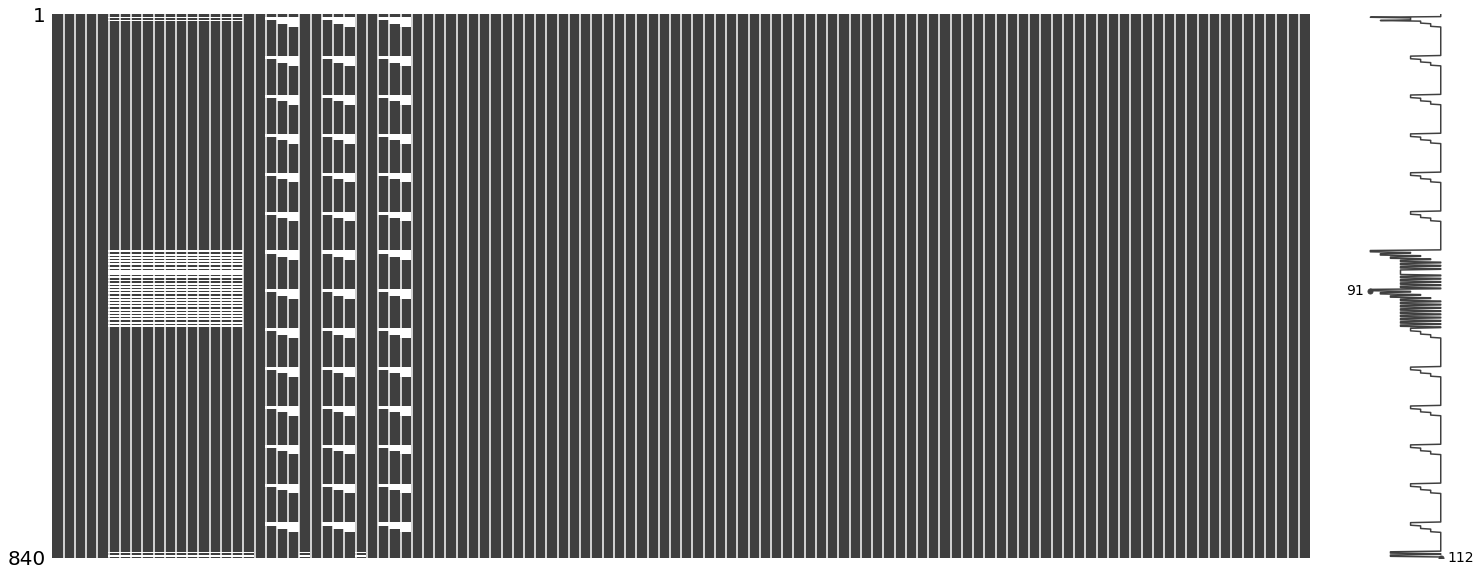

In [22]:
missingno.matrix(dataset_operational)

In [23]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
0,ndvi,9.7619
1,ndmi,9.7619
2,ndwi,9.7619
3,ndbi,9.7619
4,ndvi_mean,9.7619
...,...,...
19,lst_apr_night_mean,25.0000
20,lst_mean,0.7143
21,lst_feb_mean,8.3333
22,lst_mar_mean,16.6667


<AxesSubplot:>

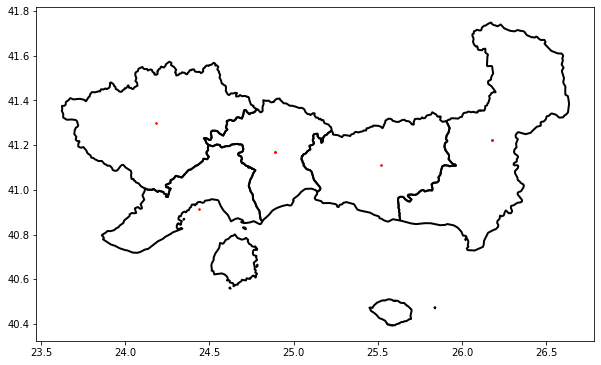

In [24]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_monthly[['NUTS3_ID']], geometry=gpd.points_from_xy(dataset_monthly.x, dataset_monthly.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [25]:
dataset_operational.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_2010_2023.csv", encoding = enc, index = False)